In [1]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr
import glob

In [2]:
table_desc = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/plots/SupTable_Sample_Stats_wGT_QC.tsv"
metadata_path = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/"

metadata_table = pd.read_csv(table_desc, sep="\t")

metadata_20x_filt = metadata_table.loc[(metadata_table.finalQC != "fail")
                              & (metadata_table.cov_chrA >= 20)
                              & (metadata_table.remove_as_relative != True)
                              & (metadata_table.remove_manual != True)
                              & (~metadata_table.ID.str.startswith("SAMEA11633"))
                             ]

In [3]:
# Loading in the kuderna mutation data and new metadata

kuderna_data = pd.read_csv("../data/science.abn7829_data_s2.csv")
# I pick out the following columns
col_species_mut = ['SPECIES_BINOMIAL', 'GENUS', 'SPECIES', 'FAMILY', 'GENERATION_LENGTH', 'MU_PER_GENERATION',
       'MU_PER_YEAR', 'EFFECTIVE_POP_SIZE']
df_species_mut = kuderna_data[col_species_mut]

metadata_dir = "/home/eriks/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/"
metadata_dirs = glob.glob(metadata_dir+"*_individuals.txt")

df_l = []
for d in metadata_dirs:
    # Identify IDs
    dir_metadata = pd.read_csv(d, sep="\t")
    df_l.append(dir_metadata)
all_inds = pd.concat(df_l)

In [4]:
def get_gamma_from_file(file):
    lines = !cat {file}
    return float([i for i in lines if 'gamma' in i][0].split(' ')[-1])
    
def get_LL_from_file(filename):
    with open(filename) as f:
        lines = f.readlines()
    return float([i for i in lines if 'likelihood' in i and 'final' in i][0].split(' ')[-1])

In [5]:
def find_best(file_list):
    best_param_file = None
    best_val = None
    # Go through the files and pick the 
    for p in file_list:
        LL = get_LL_from_file(p)
        if best_val == None:
            best_val = LL
            best_param_file = p
        if best_val < LL:
            best_val = LL
            best_param_file = p

    with open(best_param_file) as f:
        finallines = f.readlines()
    ztheta = float([i for i in finallines if 'theta' in i ][0].split(' ')[-1])
    zrho = float([i for i in finallines if 'rho' in i ][0].split(' ')[-1])
    zgamma = float([i for i in finallines if 'gamma' in i ][0].split(' ')[-1])
    file_name = best_param_file.split("/")[-1]
    zte = int(file_name.split("te")[1].split("_")[0])
    zts = int(file_name.split("ts")[1].split("_")[0])
    
    final_params = np.loadtxt(best_param_file)
    lambdaA_parameters = ",".join([str(x) for x in final_params[:,2]*ztheta/4])
    lambdaB_parameters = ",".join([str(x) for x in final_params[:,3]*ztheta/4])
    return zte, zts, ztheta, zrho, zgamma, lambdaA_parameters, lambdaB_parameters, best_param_file

In [6]:
ind_list_aut = [x.split("/")[3] for x in glob.glob("../steps/cobraa/*/aut_PSMC_final_parameters.txt*")]
len(ind_list_aut)

156

In [7]:
ind_list = [x.split("/")[3] for x in glob.glob("../steps/cobraa/*/aut_PSMC_D50_ts16_te28*")]
len(ind_list)

129

In [8]:
metadata_20x_filt.loc[(metadata_20x_filt.ID.isin(ind_list)) &
                     (metadata_20x_filt.ID.isin(ind_list_aut))].species_genotyping.unique()

array(['Allenopithecus_nigroviridis_ssp', 'Alouatta_belzebul_ssp',
       'Alouatta_discolor_ssp', 'Alouatta_juara_ssp',
       'Alouatta_macconnelli_ssp', 'Alouatta_palliata_ssp',
       'Alouatta_seniculus_ssp', 'Ateles_belzebuth_ssp',
       'Ateles_chamek_ssp', 'Ateles_geoffroyi_ssp',
       'Ateles_marginatus_ssp', 'Ateles_paniscus_ssp',
       'Brachyteles_hypoxanthus_ssp', 'Callimico_goeldii_ssp',
       'Callithrix_jacchus_ssp', 'Cebuella_niveiventris_ssp',
       'Cebuella_pygmaea_ssp', 'Mico_argentatus_ssp',
       'Mico_humeralifer_ssp', 'Carlito_syrichta_ssp',
       'Cephalopachus_bancanus_ssp', 'Tarsius_dentatus_ssp',
       'Tarsius_lariang_ssp', 'Tarsius_wallacei_ssp',
       'Cercopithecus_ascanius_ssp', 'Cercopithecus_campbelli_ssp',
       'Cercopithecus_cephus_ssp', 'Cercopithecus_denti_ssp',
       'Cercopithecus_hamlyni_ssp', 'Cercopithecus_mitis_ssp',
       'Cercopithecus_mona_ssp', 'Cercopithecus_neglectus_ssp',
       'Cercopithecus_nictitans_ssp', 'Cercopithe

In [9]:
# Check of cobraa workflow to replicate individual choices.
s_l, i_l = [], []
for g in metadata_20x_filt.genus.unique()[:]:
    # Identify IDs
    species_metadata = metadata_20x_filt.loc[metadata_20x_filt.genus == g]
    #species_metadata = species_metadata.loc[species_metadata.cov_chrX >= 5]
    # I only want females as they have a diploid chrX.
    female_df = species_metadata.loc[(species_metadata.gSEX == "F")].sort_values(by="cov_chrA", ascending=False)
    # # Restricted analysis to females - below is the way to include males if you want to run non-X analysis.
    male_df = species_metadata.loc[~(species_metadata.ID.isin(female_df.ID))].sort_values(by="cov_chrA", ascending=False)
    sorted_df = pd.concat([female_df, male_df])
    if len(sorted_df) > 0:
        sorted_input = sorted_df
    else:
        print("No usable ind for", g)
        continue
    region_metadata = pd.read_csv(metadata_dir+g+"_regions_and_batches.txt",
                           sep="\t").sort_values(by="END")
    # Go through every unique genotype calling set.
    for gvcf_folder in sorted_input.species_genotyping.unique()[:]:
        # Pick the (currently one) best individuals in the metadata.
        species_input = sorted_input.loc[sorted_input.species_genotyping == gvcf_folder]
        if len(species_input) == 1 and species_input.gSEX.iloc[0] == "M":
            continue # Skip if theres only a single male
        picked_inds = sorted_input.loc[sorted_input.species_genotyping == gvcf_folder].ID.iloc[:1]
        i_l.append(picked_inds.iloc[0])

In [10]:
len(metadata_20x_filt.loc[metadata_20x_filt.ID.isin(i_l)].species_genotyping.unique())

198

Comparing the absolute and relative improvements that the structured file allows for.

In [11]:
species_df = metadata_20x_filt.loc[(metadata_20x_filt.ID.isin(ind_list)) &
                     (metadata_20x_filt.ID.isin(ind_list_aut))]
s_l, struct_l, unstruct_l = [], [], []
for ind in species_df.ID[:]:
    species = species_df.loc[species_df.ID == ind]["species_genotyping"].iloc[0]
    structured_files = glob.glob(f'../steps/cobraa/{ind}/aut_PSMC_D50_ts*_te*_final_parameters.txt')
    zte, zts, ztheta, zrho, zgamma, lambdaA_parameters, lambdaB_parameters, best_param_file = find_best(structured_files)
    label_tag = best_param_file.split("/")[-2]
    #print(zte, zts, zgamma, best_param_file)
    struct_LL = get_LL_from_file(best_param_file)
    unstruct_LL = get_LL_from_file(f'../steps/cobraa/{ind}/aut_PSMC_final_parameters.txt')
    print(species, struct_LL, unstruct_LL, struct_LL-unstruct_LL)
    s_l.append(species), struct_l.append(struct_LL), unstruct_l.append(unstruct_LL)

Allenopithecus_nigroviridis_ssp -1420474.4665036323 -13499631.412645213 12079156.946141582
Alouatta_belzebul_ssp -39488.19014805248 -39563.39247239046 75.20232433797355
Alouatta_discolor_ssp -39531.960791240475 -39619.85687457028 87.89608332980424
Alouatta_juara_ssp -37851.22226159661 -37976.69881395649 125.4765523598835
Alouatta_macconnelli_ssp -33760.11840355809 -33834.24577684945 74.12737329136144
Alouatta_palliata_ssp -10333.242336880345 -10348.708306110431 15.465969230086557
Alouatta_seniculus_ssp -31756.78560443432 -31825.920952287892 69.13534785357115
Ateles_belzebuth_ssp -37815.894132018286 -37819.338499719306 3.444367701020383
Ateles_chamek_ssp -47455.176331506766 -47462.33437629978 7.158044793017325
Ateles_geoffroyi_ssp -51222.30502026741 -51282.05425927772 59.749239010307065
Ateles_marginatus_ssp -36580.27866557611 -36584.6576369089 4.378971332793299
Ateles_paniscus_ssp -29837.546515310783 -29840.358428906507 2.811913595724036
Brachyteles_hypoxanthus_ssp -53889.62056981756 -

Rhinopithecus_roxellana_ssp -914181.5130531547 -914257.2086755203 75.69562236557249
Saguinus_oedipus_ssp -175.02858352873204 -176.43969333096732 1.4111098022352735
Saimiri_boliviensis_ssp -296943.5888010432 -297026.4546164138 82.86581537057646
Saimiri_cassiquiarensis_ssp -187783.6098501547 -187809.4305469835 25.820696828799555
Saimiri_ustus_ssp -208197.25751796408 -208198.69266786918 1.4351499050972052
Cebus_albifrons_ssp -29113.01277741845 -29132.275609294888 19.262831876436394
Cebus_imitator_ssp -11848.398546051403 -11853.198765277873 4.80021922647029
Cebus_olivaceus_ssp -25909.218032410405 -25915.83749996819 6.619467557786265
Cebus_unicolor_ssp -35223.99139805428 -35229.737268910394 5.745870856117108
Sapajus_apella_ssp -22486.950496874237 -1780969.190069355 1758482.2395724808
Symphalangus_syndactylus_ssp -1826170.900848501 -1826836.6155534624 665.714704961516
Semnopithecus_entellus_ssp -33569.28860057878 -33578.33580129986 9.047200721077388
Semnopithecus_priam_ssp -49914.66093338921

In [12]:
LL_df = pd.DataFrame({"species": s_l, "unstructured_LL": unstruct_l, "structured_LL": struct_l})
LL_df["diff_absolute"] = LL_df.structured_LL-LL_df.unstructured_LL
LL_df["diff_relative"] = -100*(LL_df.structured_LL-LL_df.unstructured_LL)/LL_df.unstructured_LL

<Axes: xlabel='diff_relative', ylabel='Count'>

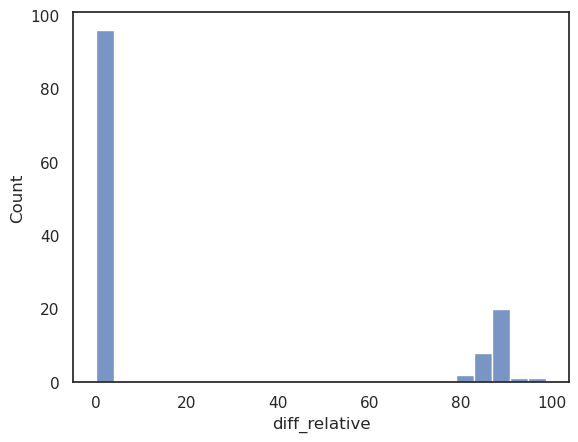

In [52]:
sns.histplot(LL_df, x="diff_relative", bins=25)

In [86]:
LL_df.loc[LL_df.diff_relative < 0.5]

,species,unstructured_LL,structured_LL,diff_absolute,diff_relative
1,Alouatta_belzebul_ssp,-39563.392472,-39488.190148,75.202324,0.190081
2,Alouatta_discolor_ssp,-39619.856875,-39531.960791,87.896083,0.221849
3,Alouatta_juara_ssp,-37976.698814,-37851.222262,125.476552,0.330404
4,Alouatta_macconnelli_ssp,-33834.245777,-33760.118404,74.127373,0.219090
5,Alouatta_palliata_ssp,-10348.708306,-10333.242337,15.465969,0.149448
...,...,...,...,...,...
123,Trachypithecus_phayrei_ssp,-42888.650283,-42875.014454,13.635829,0.031794
124,Trachypithecus_pileatus_ssp,-33825.356753,-33812.797471,12.559282,0.037130
125,Trachypithecus_poliocephalus_ssp,-7868.775091,-7867.397578,1.377513,0.017506
126,Trachypithecus_vetulus_ssp,-60907.514379,-60803.760215,103.754164,0.170347


In [95]:
LL_df.diff_relative.median()

0.030408232154831752

In [15]:
df_l = []
for s in metadata_20x_filt.species_genotyping.unique():
    f_c = len(metadata_20x_filt.loc[metadata_20x_filt.gSEX == "F"])
    if f_c == 0:
        continue
    # Read het df
    pi_df_path = "../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)
    if os.path.exists("../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)):
        pi_df = pd.read_csv(pi_df_path, sep="\t")
    else:
        print("Not present:", s)
        continue
    df_l.append(pi_df)
all_pi_df = pd.concat(df_l)

In [16]:
mean_pi_df = all_pi_df.loc[all_pi_df.callable_frac >= 0.5].groupby(["species","chr_type"])[["pi"]].mean()
mean_pi_df = mean_pi_df.reset_index().pivot(columns="chr_type", index="species", values="pi")
all_pi_df_aut = all_pi_df.loc[all_pi_df.chr_type == "aut"]
chrx_pi_df_aut = all_pi_df.loc[all_pi_df.chr_type == "chrX"]
mean_pi_df = mean_pi_df.reset_index()
mean_pi_df["CV_aut"] = (all_pi_df_aut.groupby(["species"])[["pi"]].std() / all_pi_df_aut.groupby(["species"])[["pi"]].mean()).reset_index()["pi"]
CV_x_df = (chrx_pi_df_aut.groupby(["species"])[["pi"]].std() / chrx_pi_df_aut.groupby(["species"])[["pi"]].mean()).reset_index()
mean_pi_df["CV_x"] = mean_pi_df.species.map(dict(zip(CV_x_df.species, CV_x_df.pi)))
mean_pi_df["Autosomal Pi per base"] = mean_pi_df.aut/100000
mean_pi_df["ChrX Pi per base"] = mean_pi_df.chrX/100000
mean_pi_df["X_a_ratio"] = mean_pi_df.chrX/mean_pi_df.aut
mean_pi_df["X/A ratio"] = mean_pi_df.chrX/mean_pi_df.aut

In [96]:
mean_pi_df["cobraa_LL_improvement"] = mean_pi_df.species.map(dict(zip(LL_df.species, LL_df.diff_relative)))
mean_pi_df["cobraa_admixture"] = ["Admixed" if x > 0.05 else "No Detected Admixture" for x in mean_pi_df.cobraa_LL_improvement]
mean_pi_df

chr_type,species,aut,chrX,CV_aut,CV_x,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,cobraa_LL_improvement,cobraa_admixture,Pool-Nielsen Ratio
0,Allenopithecus_nigroviridis_ssp,138.049579,76.072058,0.429676,0.842548,0.001380,0.000761,0.551049,0.551049,89.477680,Admixed,0.873702
1,Allochrocebus_lhoesti_ssp,271.244663,98.289917,0.512099,0.921961,0.002712,0.000983,0.362366,0.362366,NaN,No Detected Admixture,NaN
2,Allochrocebus_preussi_ssp,264.850665,105.876125,0.698784,0.959003,0.002649,0.001059,0.399758,0.399758,NaN,No Detected Admixture,NaN
3,Allochrocebus_solatus_ssp,302.877750,NaN,0.712146,NaN,0.003029,NaN,NaN,NaN,NaN,No Detected Admixture,NaN
4,Alouatta_belzebul_ssp,510.169378,366.218989,0.266829,0.268274,0.005102,0.003662,0.717838,0.717838,0.190081,Admixed,0.772004
...,...,...,...,...,...,...,...,...,...,...,...,...
246,Trachypithecus_poliocephalus_ssp,65.467857,38.032207,0.712469,0.680886,0.000655,0.000380,0.580929,0.580929,0.017506,No Detected Admixture,0.925400
247,Trachypithecus_vetulus_ssp,232.827177,134.729050,0.430623,0.522426,0.002328,0.001347,0.578665,0.578665,0.170347,Admixed,0.623013
248,Varecia_rubra_ssp,151.034928,NaN,0.762300,NaN,0.001510,NaN,NaN,NaN,NaN,No Detected Admixture,NaN
249,Varecia_variegata_ssp,211.144432,120.002801,0.422388,0.614984,0.002111,0.001200,0.568345,0.568345,0.096815,Admixed,0.835859


<Axes: xlabel='X/A ratio', ylabel='Count'>

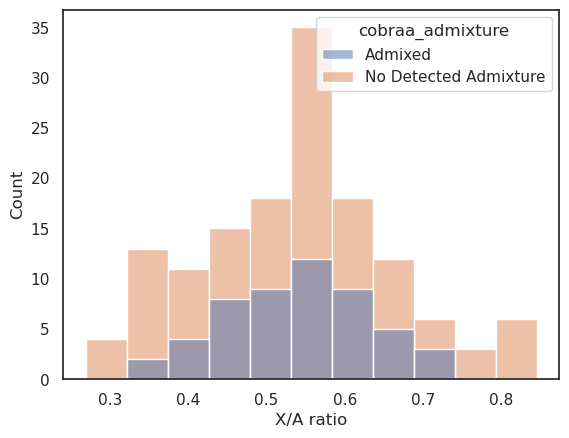

In [97]:
sns.histplot(mean_pi_df, x="X/A ratio", hue="cobraa_admixture")

<Axes: xlabel='aut', ylabel='chrX'>

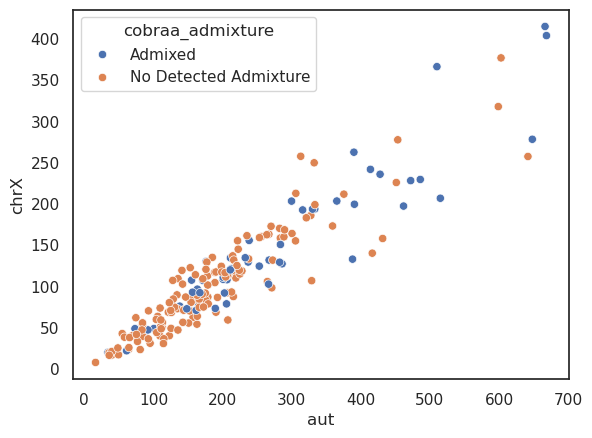

In [98]:
sns.scatterplot(mean_pi_df, x="aut", y="chrX", hue="cobraa_admixture")

In [99]:
mean_pi_df.groupby(["cobraa_admixture"])[["X/A ratio"]].mean()

chr_type,X/A ratio
cobraa_admixture,
Admixed,0.536694
No Detected Admixture,0.538895


No detectable difference - last try is Pool-Nielsen.

In [20]:
def exp_coal(g, N):
    """
    Compute expected coalescence time in epoch
    N is the number of diploid invididuals
    g is the number of generations spanned by the epoch
    """
    return 2*N - (g * np.exp(-g/(2*N))) / (1 - np.exp(-g/(2*N)))

def epoch(demog, h, i):
    "Recursively compute expected coalescence time across all epoches"
    g, N = demog[i]
    N *= h
    if i == len(demog)-1:
        return 2*N
    return (1-np.exp(-g/(2*N))) * exp_coal(g, N) + np.exp(-g/(2*N)) * (g + epoch(demog, h, i+1))

def pool_nielsen(gens, Ne, h):
    """
    Compute expected coalescence time in units of 2N
    Ne is the a list/series of Ne in the epoque.
    gens is the a list/series of generation at which an each epoque begins (the last epoque lasts forever)
    h is the relative population size, 0.75 for chrX.
    """
    epoques = list()
    for i in range(len(gens)):
        if i == 0:
            epoques.append((gens[i+1], Ne[i]))
        elif i == len(gens)-1:
            epoques.append((None, Ne[i]))    
        else:
            epoques.append((gens[i+1] - gens[i], Ne[i]))
    return epoch(epoques, h, 0)

In [84]:
s_l, pn_l = [], []
for ind in species_df.ID[:]:
    species = species_df.loc[species_df.ID == ind]["species_genotyping"].iloc[0]
    ind_inf = all_inds.loc[all_inds.GVCF_ID == label_tag]
    gs = ind_inf.GENUS.iloc[0]+"_"+ind_inf.SPECIES.iloc[0]
    gs_df = df_species_mut.loc[df_species_mut.SPECIES_BINOMIAL == gs]
    g_df = df_species_mut.loc[df_species_mut.GENUS == ind_inf.GENUS.iloc[0]] 
    if len(gs_df) > 0:
        mu = gs_df.MU_PER_GENERATION.mean()
        gen = gs_df.GENERATION_LENGTH.mean()
        kuderna_Ne = gs_df.EFFECTIVE_POP_SIZE.mean()
    elif len(g_df) > 0:
        mu = g_df.MU_PER_GENERATION.mean()
        gen = g_df.GENERATION_LENGTH.mean()
        kuderna_Ne = g_df.EFFECTIVE_POP_SIZE.mean()
    #print(mu, gen)
    final_params = np.loadtxt(f'../steps/cobraa/{ind}/aut_PSMC_final_parameters.txt')
    time_array = list(final_params[:,1])
    time_array.insert(0,0)
    time_array = np.array(time_array)
    pn_ratio = pool_nielsen((final_params[:,1]/mu)*gen, (1/final_params[:,2])/mu, 0.75) / \
                pool_nielsen((final_params[:,1]/mu)*gen, (1/final_params[:,2])/mu, 1)
    print(pn_ratio)
    s_l.append(species), pn_l.append(pn_ratio)

0.8737017525220963
0.7720042060524512
0.8813495287825291
0.7120543211517439
0.7624345045595058
0.7453374577998603
0.8349369474231566
0.6802745652923504
0.7248676582136346
0.7639877344237137
0.6660003257284038
0.6296567989374925
0.5121809199157682
0.59285432274274
0.8636732864520872
0.7272015773522468
0.6496489113996152
0.8328995783982933
0.7040014827362353
0.7390655541414646
0.6322978220439441
0.655716194068143
0.8881278079951733
0.8630861089279038
0.6636319134563717
0.7100523415399232
0.809083387388898
0.7350664857959747
0.8083793169960745
0.7823287234802886
0.715631194491719
0.7939536532123695
0.657073081225815
0.45648990494539904
0.8067319278163838
0.799283550564406
0.8761580487814656
0.9012750100137915
0.8328276376293988
0.5779349899984694
0.7613188782190221
0.8747811447804529
0.7472586462849565
0.7319420965276697
0.6433595701658311
0.6655817264109051
0.9180836563471126
0.8816419519912143
0.7685480739950946
0.6121612604439197
0.6484760623219404
0.659571120042239
0.7179109170916068


In [102]:
(final_params[:,1]/mu)*gen

array([3.88608514e+04, 4.52415268e+04, 5.26698637e+04, 6.13178807e+04,
       7.13858406e+04, 8.31068879e+04, 9.67524479e+04, 1.12638512e+05,
       1.31132954e+05, 1.52664053e+05, 1.77730404e+05, 2.06912473e+05,
       2.40886029e+05, 2.80437802e+05, 3.26483694e+05, 3.80089995e+05,
       4.42498069e+05, 5.15153104e+05, 5.99737580e+05, 6.98210225e+05,
       8.12851378e+05, 9.46315793e+05, 1.10169412e+06, 1.28258445e+06,
       1.49317570e+06, 1.73834453e+06, 2.02376834e+06, 2.35605671e+06,
       2.74290446e+06, 3.19326986e+06, 3.71758206e+06, 4.32798260e+06,
       5.03860656e+06, 5.86590992e+06, 6.82905061e+06, 7.95033215e+06,
       9.25572014e+06, 1.07754436e+07, 1.25446948e+07, 1.46044444e+07,
       1.70023903e+07, 1.97940619e+07, 2.30441061e+07, 2.68277844e+07,
       3.12327158e+07, 3.63609056e+07, 4.23311077e+07, 4.92815745e+07,
       5.73732585e+07, 6.67935395e+07])

In [101]:
(1/final_params[:,2])/mu

array([2111915.95565308, 2111915.95565308, 2111915.95565308,
       2111915.95565308, 2111915.95565308, 2111915.95565308,
       2111915.95565308, 2111915.95565308, 2111915.95565308,
       2111915.95565308, 2111915.95565308, 1957772.69546552,
        493706.54442701,  241758.55831344,  177222.98967037,
        164074.58789875,  183129.55508722,  222118.62389081,
        258563.02002325,  271246.05763541,  256804.1338282 ,
        227373.00759382,  197025.25515882,  173547.21764346,
        158795.81474866,  152016.23122848,  151884.07863234,
        156893.95344215,  164919.35647667,  173505.63077144,
        180871.18975038,  186744.0209676 ,  192187.90562933,
        198687.79013727,  208313.13550251,  223005.39306647,
        244064.28481413,  271957.71310009,  306979.44830748,
        348712.1934415 ,  395604.61634518,  445625.20681693,
        497840.99128739,  553077.13377725,  618812.26645618,
        714774.41888432,  871128.72106936, 1094880.66088064,
       1281522.62348188,

<Axes: xlabel='Pool-Nielsen Ratio', ylabel='X/A ratio'>

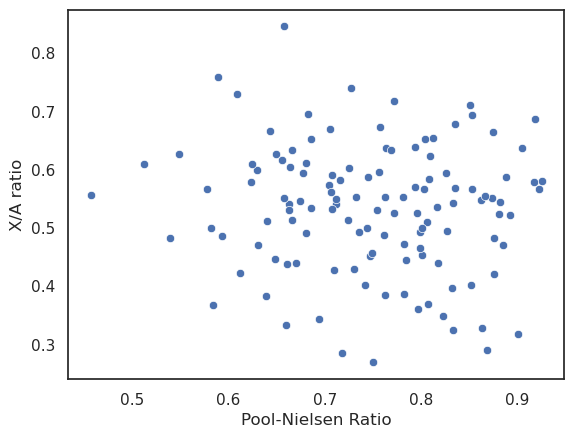

In [85]:
mean_pi_df["Pool-Nielsen Ratio"] = mean_pi_df.species.map(dict(zip(s_l, pn_l)))
sns.scatterplot(mean_pi_df, x="Pool-Nielsen Ratio", y="X/A ratio")